In [1]:
!pip install -U ultralytics roboflow pyyaml pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: 

In [2]:
# =========================
# Project Config
# =========================
# Roboflow 프로젝트 정보
ROBOFLOW_WORKSPACE = "2026-oss"
ROBOFLOW_PROJECT = "ai-picture-book-object-detection"

# Roboflow 최신 통합 데이터셋 버전
ROBOFLOW_VERSION = 10

# 사용할 YOLO 모델과 학습 run 이름
MODEL_NAME = "yolo11n.pt"
RUN_NAME = "picture_book_yolo11n_v10"

# 학습 설정
IMG_SIZE = 640
EPOCHS = 100
BATCH_SIZE = 16
CONF_THRESHOLD = 0.25

In [3]:
# Colab에서 GPU가 정상적으로 연결되었는지 확인
!nvidia-smi

Wed Jun 17 17:12:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

print("Roboflow API Key loaded:", ROBOFLOW_API_KEY is not None)

Roboflow API Key loaded: True


In [5]:
# Roboflow에서 v3 데이터셋 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)

# "yolov8"은 모델명이 아니라 데이터셋 export format임
# 실제 학습 모델은 아래에서 YOLO("yolo11n.pt")로 지정함
dataset = project.version(10).download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AI-Picture-Book-Object-Detection-10 in yolov8:: 100%|██████████| 3263/3263 [00:00<00:00, 4713.14it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/AI-Picture-Book-Object-Detection-10


In [6]:
# Roboflow API Key를 Colab Secrets에서 불러오고, 없으면 직접 입력받음
from getpass import getpass

try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
except Exception:
    ROBOFLOW_API_KEY = None

if not ROBOFLOW_API_KEY:
    ROBOFLOW_API_KEY = getpass("Roboflow API Key를 입력하세요: ")

# 앞뒤 공백 제거
ROBOFLOW_API_KEY = ROBOFLOW_API_KEY.strip()

print("Roboflow API Key loaded:", ROBOFLOW_API_KEY is not None and len(ROBOFLOW_API_KEY) > 0)
print("API Key length:", len(ROBOFLOW_API_KEY))

Roboflow API Key loaded: True
API Key length: 20


In [7]:
# data.yaml 파일을 확인하고, 학습 경로를 절대경로로 보정
import os
import yaml

yaml_path = os.path.join(dataset.location, "data.yaml")

print("Original data.yaml path:", yaml_path)

with open(yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

print("Original data.yaml:")
print(data_yaml)

# 경로 오류를 줄이기 위해 train/valid/test 이미지 경로를 절대경로로 수정
data_yaml["train"] = os.path.join(dataset.location, "train", "images")
data_yaml["val"] = os.path.join(dataset.location, "valid", "images")
data_yaml["test"] = os.path.join(dataset.location, "test", "images")

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print("\nUpdated data.yaml:")
with open(yaml_path, "r", encoding="utf-8") as f:
    print(f.read())

Original data.yaml path: /content/AI-Picture-Book-Object-Detection-10/data.yaml
Original data.yaml:
{'names': ['book_flower', 'book_flowerpot', 'book_monkey', 'book_stone', 'braille', 'tactile_flower', 'tactile_flowerpot', 'tactile_monkey', 'tactile_stone', 'text'], 'nc': 10, 'roboflow': {'license': 'MIT', 'project': 'ai-picture-book-object-detection', 'url': 'https://universe.roboflow.com/2026-oss/ai-picture-book-object-detection/dataset/10', 'version': 10, 'workspace': '2026-oss'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Updated data.yaml:
names:
- book_flower
- book_flowerpot
- book_monkey
- book_stone
- braille
- tactile_flower
- tactile_flowerpot
- tactile_monkey
- tactile_stone
- text
nc: 10
roboflow:
  license: MIT
  project: ai-picture-book-object-detection
  url: https://universe.roboflow.com/2026-oss/ai-picture-book-object-detection/dataset/10
  version: 10
  workspace: 2026-oss
test: /content/AI-Picture-Book-Object-Detection-10/test/i

In [8]:
# v10 데이터셋에 10개 클래스가 모두 포함되어 있는지 확인

EXPECTED_CLASSES = [
    "book_flower",
    "book_flowerpot",
    "book_monkey",
    "book_stone",
    "braille",
    "tactile_flower",
    "tactile_flowerpot",
    "tactile_monkey",
    "tactile_stone",
    "text",
]

with open(yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

names = data_yaml.get("names")

# names가 dict 또는 list 형태일 수 있으므로 둘 다 처리
if isinstance(names, dict):
    actual_classes = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]
else:
    actual_classes = names

print("Actual classes:")
for idx, name in enumerate(actual_classes):
    print(f"{idx}: {name}")

print("\nExpected class count:", len(EXPECTED_CLASSES))
print("Actual class count:", len(actual_classes))

missing_classes = sorted(set(EXPECTED_CLASSES) - set(actual_classes))
extra_classes = sorted(set(actual_classes) - set(EXPECTED_CLASSES))

print("\nMissing classes:", missing_classes)
print("Extra classes:", extra_classes)

assert len(actual_classes) == len(EXPECTED_CLASSES), "클래스 개수가 예상과 다릅니다."
assert set(actual_classes) == set(EXPECTED_CLASSES), "클래스 목록이 예상과 다릅니다."

print("\n클래스 검증 완료: v10 데이터셋에 10개 클래스가 모두 포함되어 있습니다.")

Actual classes:
0: book_flower
1: book_flowerpot
2: book_monkey
3: book_stone
4: braille
5: tactile_flower
6: tactile_flowerpot
7: tactile_monkey
8: tactile_stone
9: text

Expected class count: 10
Actual class count: 10

Missing classes: []
Extra classes: []

클래스 검증 완료: v10 데이터셋에 10개 클래스가 모두 포함되어 있습니다.


In [9]:
# train, valid, test 데이터가 정상적으로 나뉘어 있는지 확인
import glob

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(dataset.location, split, "images")
    label_dir = os.path.join(dataset.location, split, "labels")

    image_count = len(glob.glob(os.path.join(image_dir, "*")))
    label_count = len(glob.glob(os.path.join(label_dir, "*")))

    print(f"{split}: images={image_count}, labels={label_count}")

train: images=1425, labels=1425
valid: images=136, labels=136
test: images=68, labels=68


In [10]:
# YOLO11n 모델을 불러와 v3 데이터셋으로 학습
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=yaml_path,
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    name=RUN_NAME,
    project="runs/detect"
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AI-Picture-Book-Object-Detection-10/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=picture_book_yolo11n_v10, nbs=64, nms=False, opset=None, optimize=False, opt

In [11]:
# YOLO11n v10 학습 결과의 best.pt 경로 확인
from pathlib import Path

best_weights = [
    path for path in Path("/content").rglob("best.pt")
    if RUN_NAME in str(path)
]

best_weights = sorted(best_weights)

print("best.pt files:")
for path in best_weights:
    print(path)

assert len(best_weights) > 0, "YOLO11n v10 best.pt 파일을 찾지 못했습니다."

best_model_path = str(best_weights[-1])

print("\nBest model path:", best_model_path)

best.pt files:
/content/runs/detect/runs/detect/picture_book_yolo11n_v10/weights/best.pt

Best model path: /content/runs/detect/runs/detect/picture_book_yolo11n_v10/weights/best.pt


In [12]:
# best.pt 모델을 test set 기준으로 평가
best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=yaml_path,
    split="test",
    imgsz=IMG_SIZE
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1291.8±307.3 MB/s, size: 39.5 KB)
val: Scanning /content/AI-Picture-Book-Object-Detection-10/test/labels... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 1.8Kit/s 0.0s
val: New cache created: /content/AI-Picture-Book-Object-Detection-10/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 24, len(boxes) = 73. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s
                   all         68         73      0.894      0.781      0.831      0.647
           book_flower        

In [13]:
# 전체 성능 지표 정리
summary = {
    "model": MODEL_NAME,
    "dataset_version": ROBOFLOW_VERSION,
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP@0.5": float(metrics.box.map50),
    "mAP@0.5:0.95": float(metrics.box.map),
    "best_model_path": best_model_path,
}

summary

{'model': 'yolo11n.pt',
 'dataset_version': 10,
 'precision': 0.8936409899056452,
 'recall': 0.7805967764340591,
 'mAP@0.5': 0.8310689854005643,
 'mAP@0.5:0.95': 0.6474503322992797,
 'best_model_path': '/content/runs/detect/runs/detect/picture_book_yolo11n_v10/weights/best.pt'}

In [14]:
# 클래스별 mAP 성능 확인
import pandas as pd

class_result_rows = []

ap50_values = getattr(metrics.box, "ap50", None)
ap_values = getattr(metrics.box, "ap", None)

for idx, class_name in enumerate(actual_classes):
    row = {
        "class_id": idx,
        "class_name": class_name,
        "mAP@0.5": float(ap50_values[idx]) if ap50_values is not None and idx < len(ap50_values) else None,
        "mAP@0.5:0.95": float(ap_values[idx]) if ap_values is not None and idx < len(ap_values) else None,
    }
    class_result_rows.append(row)

class_results_df = pd.DataFrame(class_result_rows)
class_results_df

,class_id,class_name,mAP@0.5,mAP@0.5:0.95
0,0,book_flower,0.995000,0.592700
1,1,book_flowerpot,0.910065,0.629003
2,2,book_monkey,0.893095,0.659548
3,3,book_stone,0.665000,0.598500
4,4,braille,0.825909,0.731451
5,5,tactile_flower,0.665000,0.599000
6,6,tactile_flowerpot,0.722643,0.584381
7,7,tactile_monkey,0.795000,0.548333
8,8,tactile_stone,0.995000,0.888750
9,9,text,0.843978,0.642838


In [15]:
# 평가 결과를 JSON, CSV 파일로 저장
import json

os.makedirs("results", exist_ok=True)

summary_path = "results/yolo11n_v10_summary.json"
class_result_path = "results/yolo11n_v10_class_results.csv"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

class_results_df.to_csv(class_result_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
print("Saved class results:", class_result_path)

Saved summary: results/yolo11n_v10_summary.json
Saved class results: results/yolo11n_v10_class_results.csv


In [16]:
# test 이미지에 대해 실제 예측 결과 저장
test_image_path = os.path.join(dataset.location, "test", "images")

predict_results = best_model.predict(
    source=test_image_path,
    conf=CONF_THRESHOLD,
    save=True,
    name=f"{RUN_NAME}_test_predictions"
)


image 1/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flower_0008_jpg.rf.037ec5b92fb2d319e72bd8191f9e8872.jpg: 640x640 1 book_flower, 9.0ms
image 2/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flower_0016_jpg.rf.12d96b64cedcd601f418c06464bb1354.jpg: 640x640 1 book_flower, 8.0ms
image 3/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flower_0025_jpg.rf.0f6b58ae1771eb924e55e84e2d9d1154.jpg: 640x640 1 book_flower, 7.9ms
image 4/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flower_0034_jpg.rf.6ace9c1d397ab45f27851cadfcd054d6.jpg: 640x640 1 book_flower, 7.9ms
image 5/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flower_0038_jpg.rf.eee736803a2d92309159376e8a1fb624.jpg: 640x640 1 book_flower, 7.9ms
image 6/68 /content/AI-Picture-Book-Object-Detection-10/test/images/book_flowerpot_0007_jpg.rf.b7d817eac7c7e7c1f07ed68a4903f058.jpg: 640x640 1 book_flowerpot, 7.9ms
image 7/68 /content/AI-Picture-Book-Obj

Detected images: 68


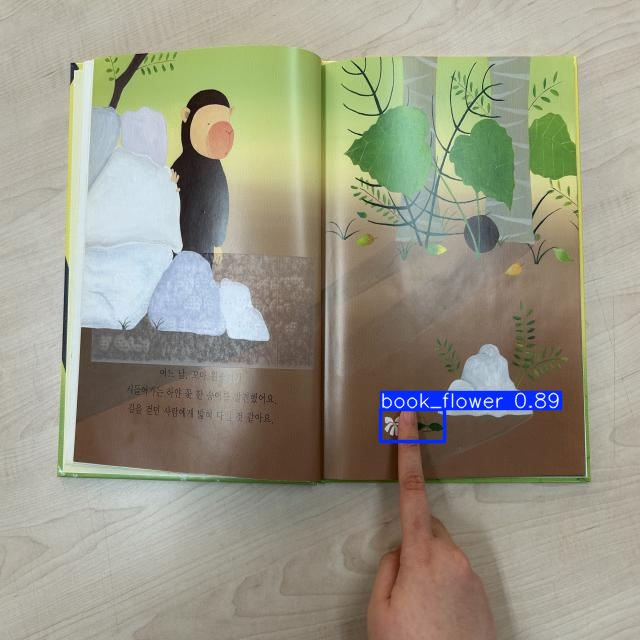

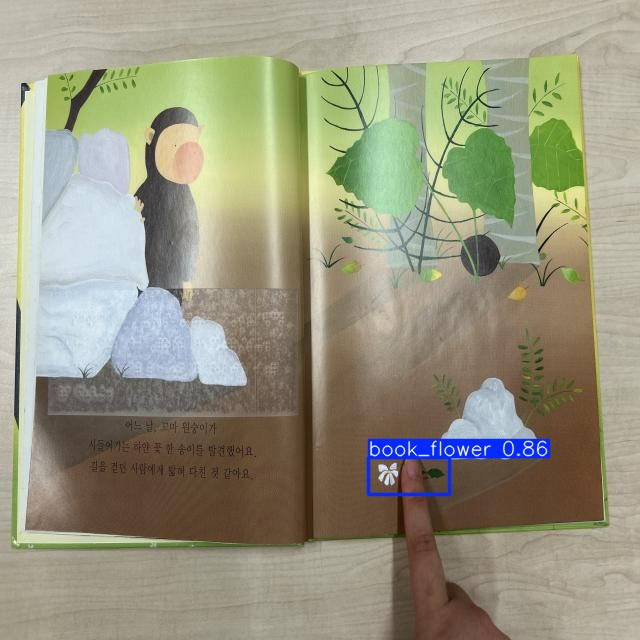

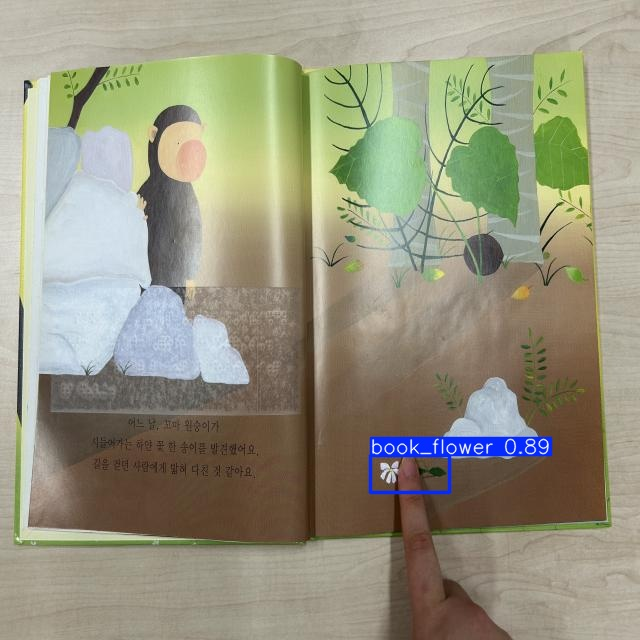

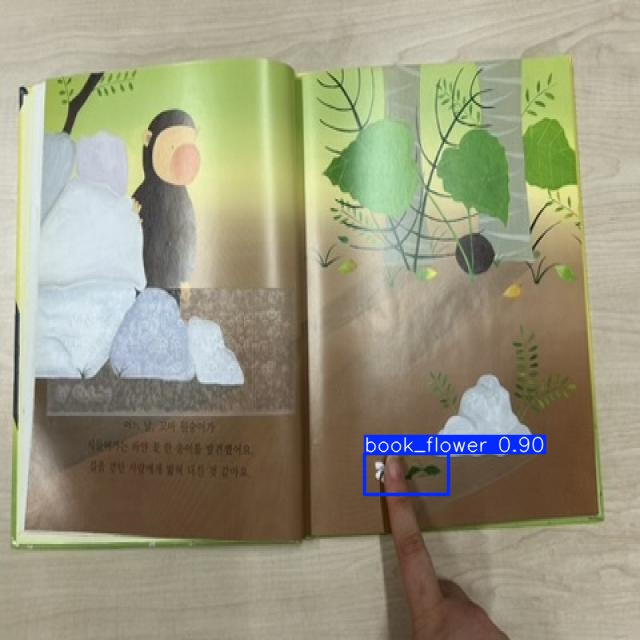

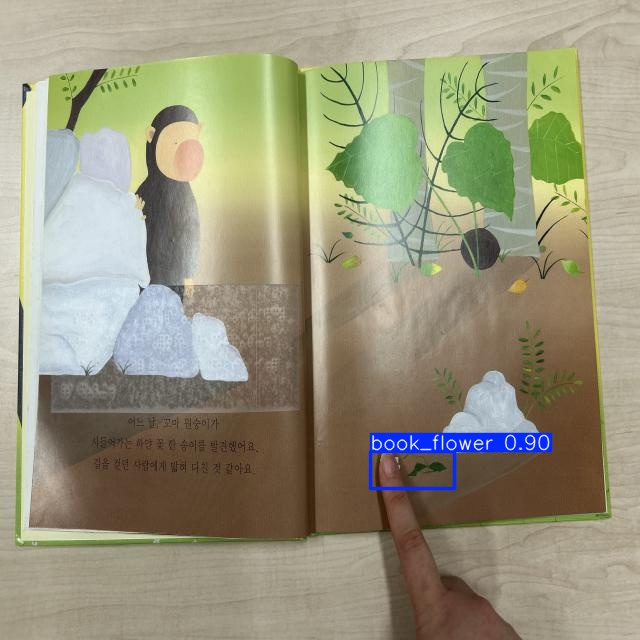

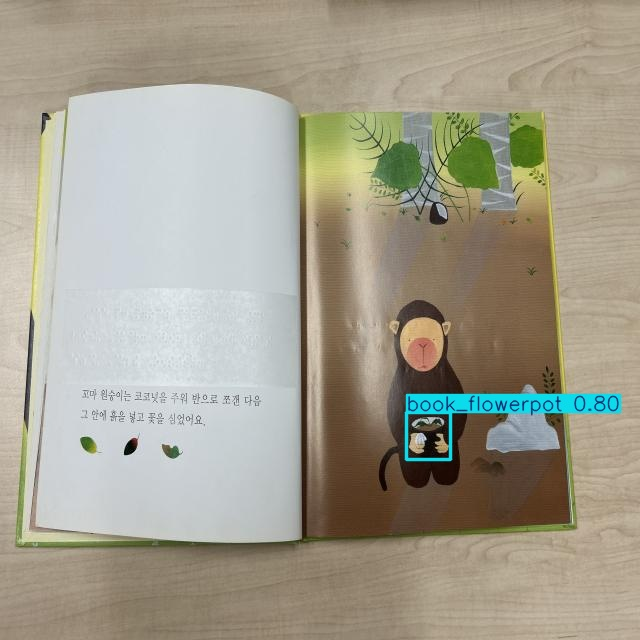

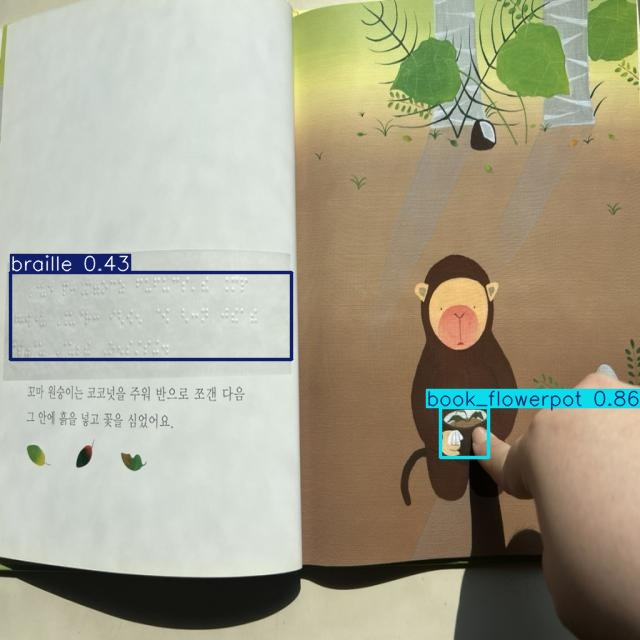

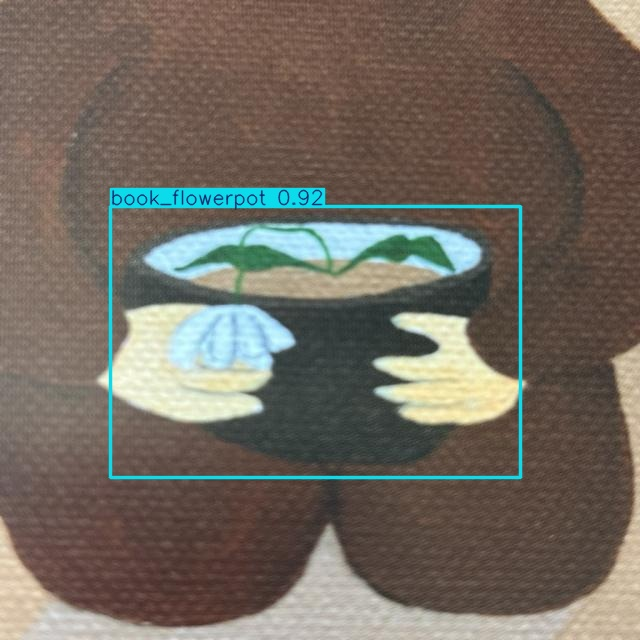

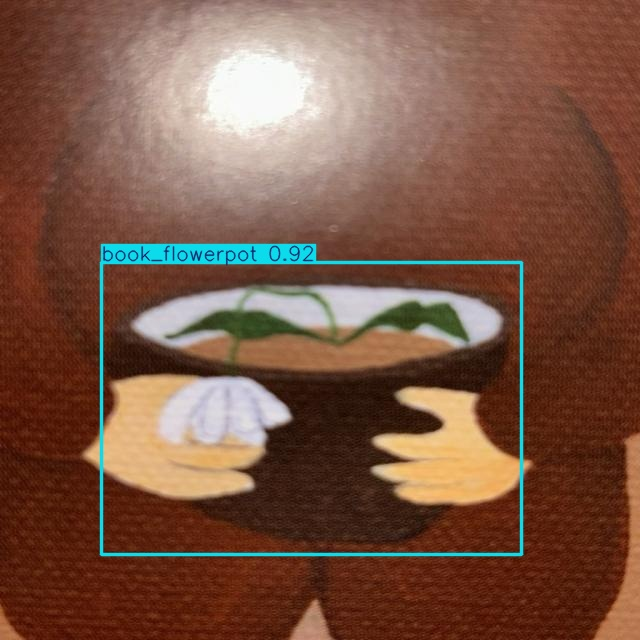

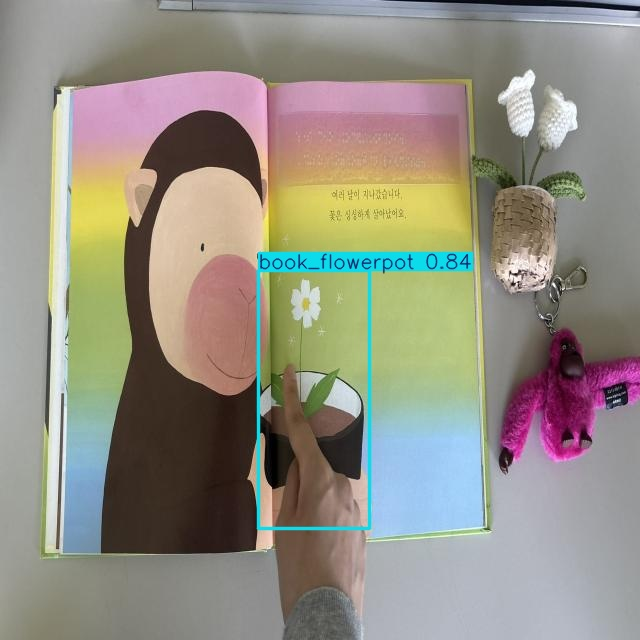

In [17]:
# 저장된 예측 결과 이미지 일부 확인
from IPython.display import Image, display

result_images = sorted(glob.glob(f"runs/detect/{RUN_NAME}_test_predictions*/*.jpg"))

print("Detected images:", len(result_images))

for img_path in result_images[:10]:
    display(Image(filename=img_path))

In [18]:
# 백엔드 연동 시 필요한 모델 정보 정리
model_info = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "dataset_version": ROBOFLOW_VERSION,
    "input": {
        "type": "image_or_webcam_frame",
        "image_size": IMG_SIZE,
    },
    "output": {
        "class_name": "detected object class",
        "confidence": "detection confidence score",
        "bbox": "[x1, y1, x2, y2]",
    },
    "classes": actual_classes,
    "best_model_path": best_model_path,
    "metrics": summary,
}

model_info_path = "results/yolo11n_v10_model_info.json"

with open(model_info_path, "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print("Saved model info:", model_info_path)
model_info

Saved model info: results/yolo11n_v10_model_info.json


{'model_name': 'yolo11n.pt',
 'run_name': 'picture_book_yolo11n_v10',
 'dataset_version': 10,
 'input': {'type': 'image_or_webcam_frame', 'image_size': 640},
 'output': {'class_name': 'detected object class',
  'confidence': 'detection confidence score',
  'bbox': '[x1, y1, x2, y2]'},
 'classes': ['book_flower',
  'book_flowerpot',
  'book_monkey',
  'book_stone',
  'braille',
  'tactile_flower',
  'tactile_flowerpot',
  'tactile_monkey',
  'tactile_stone',
  'text'],
 'best_model_path': '/content/runs/detect/runs/detect/picture_book_yolo11n_v10/weights/best.pt',
 'metrics': {'model': 'yolo11n.pt',
  'dataset_version': 10,
  'precision': 0.8936409899056452,
  'recall': 0.7805967764340591,
  'mAP@0.5': 0.8310689854005643,
  'mAP@0.5:0.95': 0.6474503322992797,
  'best_model_path': '/content/runs/detect/runs/detect/picture_book_yolo11n_v10/weights/best.pt'}}